<a href="https://colab.research.google.com/github/Sai-chidwilas039/enterprise-data-reconciliation/blob/main/Enterprise_Data_Reconciliation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect('/content/enterprise_database (1).db')
logs = pd.read_csv('/content/server_logs (1).txt')
rates = pd.read_csv('/content/daily_exchange_rates (1).csv', parse_dates=['Date'])

In [3]:
print(pd.read_sql("SELECT name FROM sqlite_master", conn))
print(pd.read_sql("SELECT COUNT(*) AS rows FROM users", conn))

    name
0  users
    rows
0  47464


In [4]:
query = """
SELECT user_id, name, status, updated_at
FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC) AS rn
    FROM users
)
WHERE rn = 1 AND status = 'Active'
"""
df_active_users = pd.read_sql(query, conn)
print(len(df_active_users))   # expect 14183

14183


In [5]:
# 1. Load the logs (one column called Raw_Server_Log)
logs = pd.read_csv('/content/server_logs (1).txt')
print(logs.shape)   # expect (100000, 1)

# 2. Drop the ERROR rows
logs = logs[~logs['Raw_Server_Log'].str.contains('ERROR')]
print(len(logs))    # expect 94902

# 3. Extract Date, User ID, Product ID, Euro Value with regex
pattern = r'\[(?P<Date>\d{4}-\d{2}-\d{2}).*?(?P<User_ID>U-\d+).*?(?P<Product_ID>PRD-\d+).*?eur_val\W+(?P<Euro_Value>[\d.]+)'
extracted_data = logs['Raw_Server_Log'].str.extract(pattern)

# 4. Fix the data types
extracted_data['Date'] = pd.to_datetime(extracted_data['Date'])
extracted_data['Euro_Value'] = extracted_data['Euro_Value'].astype(float)

# 5. Check the result
print(extracted_data.isna().sum())   # all zeros means every row matched
extracted_data.head()

(100000, 1)
94902
Date          0
User_ID       0
Product_ID    0
Euro_Value    0
dtype: int64


,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
2,2023-05-09,U-18932,PRD-905,3406.21
3,2023-10-21,U-15882,PRD-284,164.08
4,2023-01-10,U-22781,PRD-665,26.80
5,2023-05-23,U-13348,PRD-589,4964.77


In [6]:
# 1. Load the exchange rates
rates = pd.read_csv('/content/daily_exchange_rates (1).csv', parse_dates=['Date'])
print(rates['EUR_to_USD'].isna().sum())   # expect 104 missing

# 2. Fill the gaps (weekends + holidays)
rates['EUR_to_USD'] = rates['EUR_to_USD'].ffill().bfill()
print(rates['EUR_to_USD'].isna().sum())   # expect 0

# 3. Join transactions to exchange rates by date
df = extracted_data.merge(rates, on='Date', how='left')
print(len(df))                            # expect 94902
print(df['EUR_to_USD'].isna().sum())      # expect 0

# 4. Join to the active users from Phase 1
df_final = df.merge(df_active_users, left_on='User_ID', right_on='user_id', how='inner')

# 5. Calculate USD revenue
df_final['USD_Revenue'] = df_final['Euro_Value'] * df_final['EUR_to_USD']

print(len(df_final))                      # expect 53899
df_final.head()

104
0
94902
0
53899


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,user_id,name,status,updated_at,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,U-19484,User_U-19484,Active,2023-01-11 14:00:00,4011.220772
1,2023-10-21,U-15882,PRD-284,164.08,1.075350,U-15882,User_U-15882,Active,2023-01-16 14:00:00,176.443420
2,2023-01-10,U-22781,PRD-665,26.80,1.127128,U-22781,User_U-22781,Active,2023-01-07 14:00:00,30.207030
3,2023-10-20,U-22062,PRD-363,48.63,1.075350,U-22062,User_U-22062,Active,2023-01-05 14:00:00,52.294268
4,2023-12-02,U-22146,PRD-223,960.60,1.066142,U-22146,User_U-22146,Active,2023-01-18 14:00:00,1024.135923


Month
2023-01    12841761.0
2023-02    11436131.0
2023-03    12348932.0
2023-04    12015376.0
2023-05    12333644.0
2023-06    12084356.0
2023-07    12444164.0
2023-08    12812731.0
2023-09    12228952.0
2023-10    12501330.0
2023-11    12588223.0
2023-12    12639023.0
Name: USD_Revenue, dtype: float64
User_ID
U-06582    40051.0
U-23313    39556.0
U-03805    39530.0
U-20018    38650.0
U-06489    38629.0
Name: USD_Revenue, dtype: float64


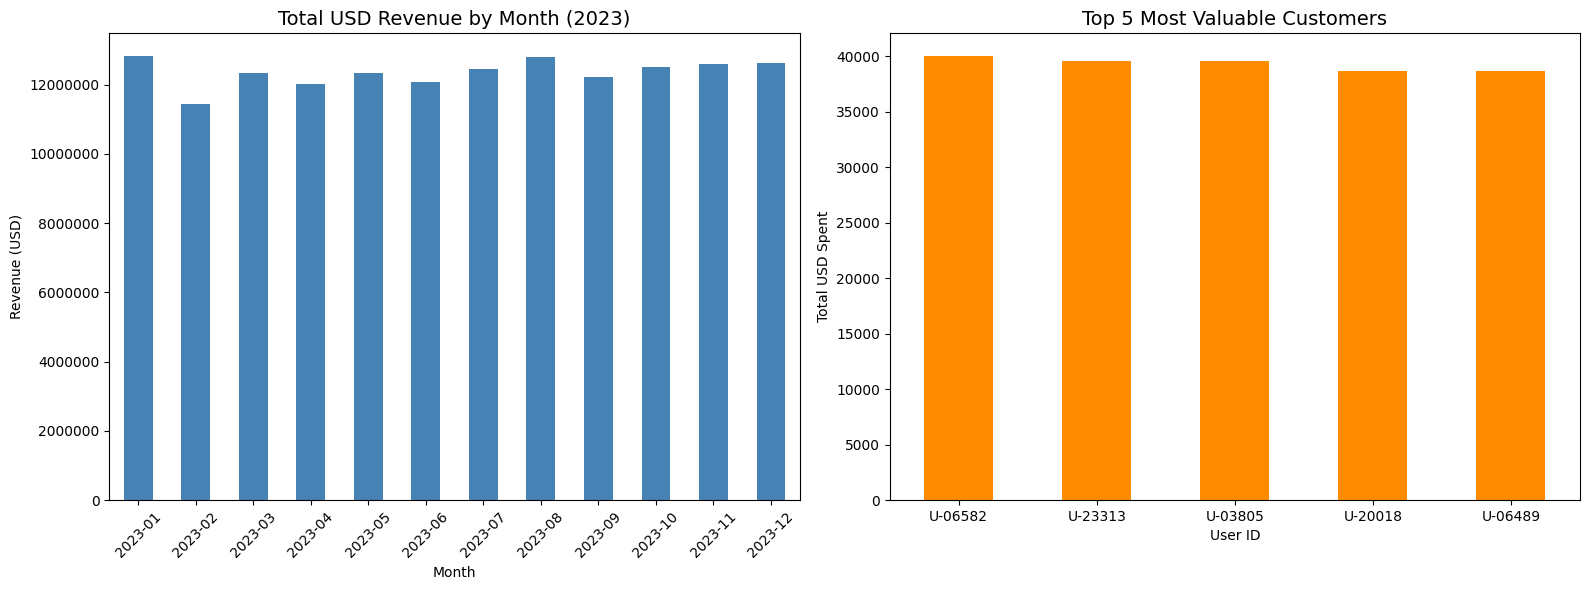

In [7]:
# 1. Create a Month column
df_final['Month'] = df_final['Date'].dt.to_period('M').astype(str)

# 2. Total USD revenue by month
monthly = df_final.groupby('Month')['USD_Revenue'].sum()
print(monthly.round(0))

# 3. Top 5 customers by total USD spent
top5 = df_final.groupby('User_ID')['USD_Revenue'].sum().nlargest(5)
print(top5.round(0))

# 4. Two charts side by side
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

monthly.plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Total USD Revenue by Month (2023)', fontsize=14)
ax[0].set_xlabel('Month')
ax[0].set_ylabel('Revenue (USD)')
ax[0].tick_params(axis='x', rotation=45)
ax[0].ticklabel_format(style='plain', axis='y')

top5.plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title('Top 5 Most Valuable Customers', fontsize=14)
ax[1].set_xlabel('User ID')
ax[1].set_ylabel('Total USD Spent')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

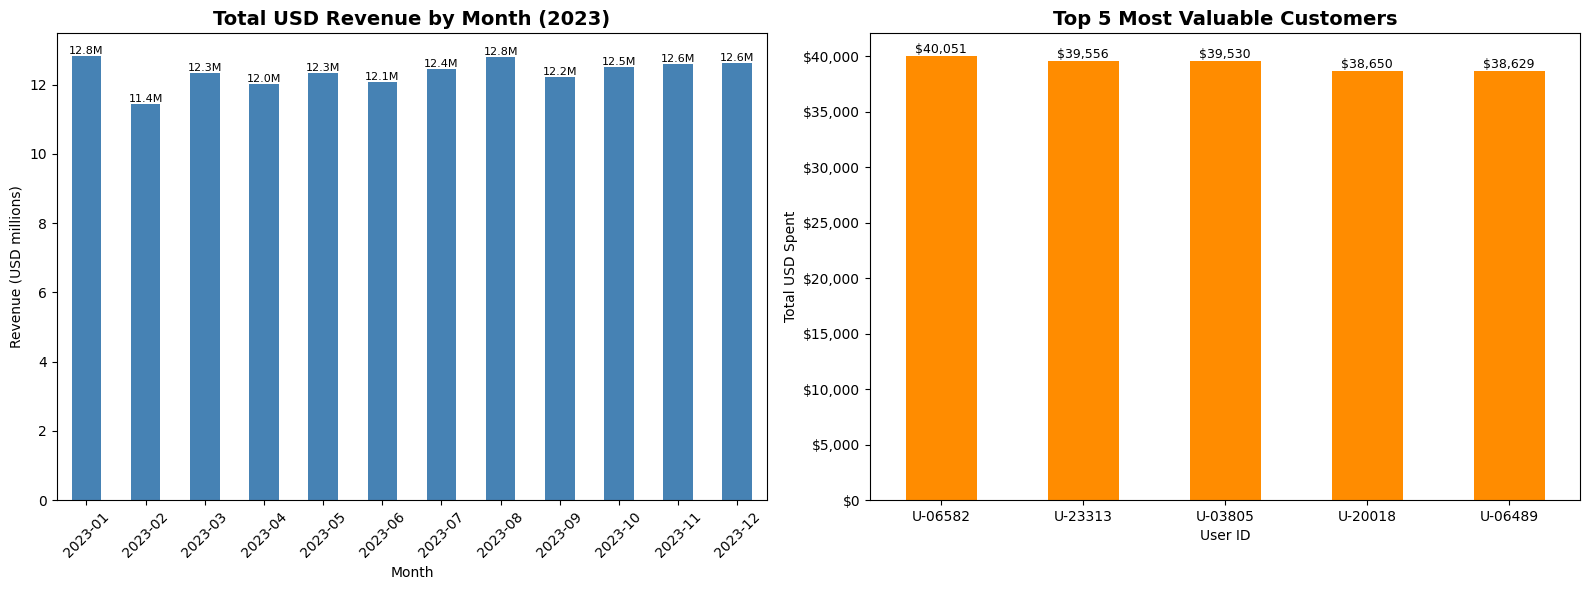

In [8]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: monthly revenue in $ millions
(monthly / 1e6).plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Total USD Revenue by Month (2023)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Month'); ax[0].set_ylabel('Revenue (USD millions)')
ax[0].tick_params(axis='x', rotation=45)
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_height():.1f}M', (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom', fontsize=8)

# Chart 2: top 5 customers
top5.plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title('Top 5 Most Valuable Customers', fontsize=14, fontweight='bold')
ax[1].set_xlabel('User ID'); ax[1].set_ylabel('Total USD Spent')
ax[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax[1].tick_params(axis='x', rotation=0)
for p in ax[1].patches:
    ax[1].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Key Findings

**1. Revenue is stable.**
Monthly revenue stays around $12M all year (range: $11.4M to $12.8M).
February is the lowest month at about $11.4M, likely because it has fewer days.

**2. Data reduction after cleaning.**
- 100,000 raw log lines
- 94,902 valid transactions after removing ERROR rows
- 53,899 transactions after keeping only Active users

Transactions from Pending and Suspended users were excluded. In a real
project I would confirm with Finance whether those should count as revenue.

**3. No heavy dependence on a few customers.**
The top 5 customers each spent about $39K, which is a small share of total
revenue. Losing one customer would not hurt revenue much.